In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
iris = load_iris(as_frame=True)
df = iris.frame

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df = df[df["target"] != 2].copy()

In [6]:
x = df["petal length (cm)"].values
y = df["target"].values

In [7]:
x_mean = x.mean()
x_std = x.std()

x_scaled = (x - x_mean) / x_std

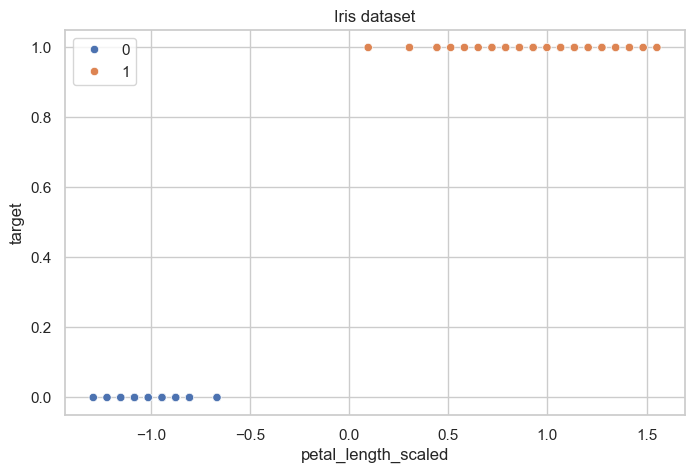

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=x_scaled,
    y=y,
    hue=y,
    palette="deep"
)

plt.xlabel("petal_length_scaled")
plt.ylabel("target")

plt.title("Iris dataset");

In [9]:
with pm.Model() as logistic_model:

    alpha = pm.Normal("alpha", mu=0, sigma=10)

    beta = pm.Normal("beta", mu=0, sigma=10)

    mu = alpha + beta * x_scaled

    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(mu)
    )

    y_obs = pm.Bernoulli(
        "y_obs",
        p=p,
        observed=y
    )

    trace_logistic = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1 seconds.


In [10]:
az.summary(
    trace_logistic,
    var_names=["alpha", "beta"]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.128,3.438,-2.514,10.044,0.100,0.080,1381.0,1476.0,1.0
beta,15.002,5.640,5.862,25.673,0.149,0.096,1476.0,2300.0,1.0


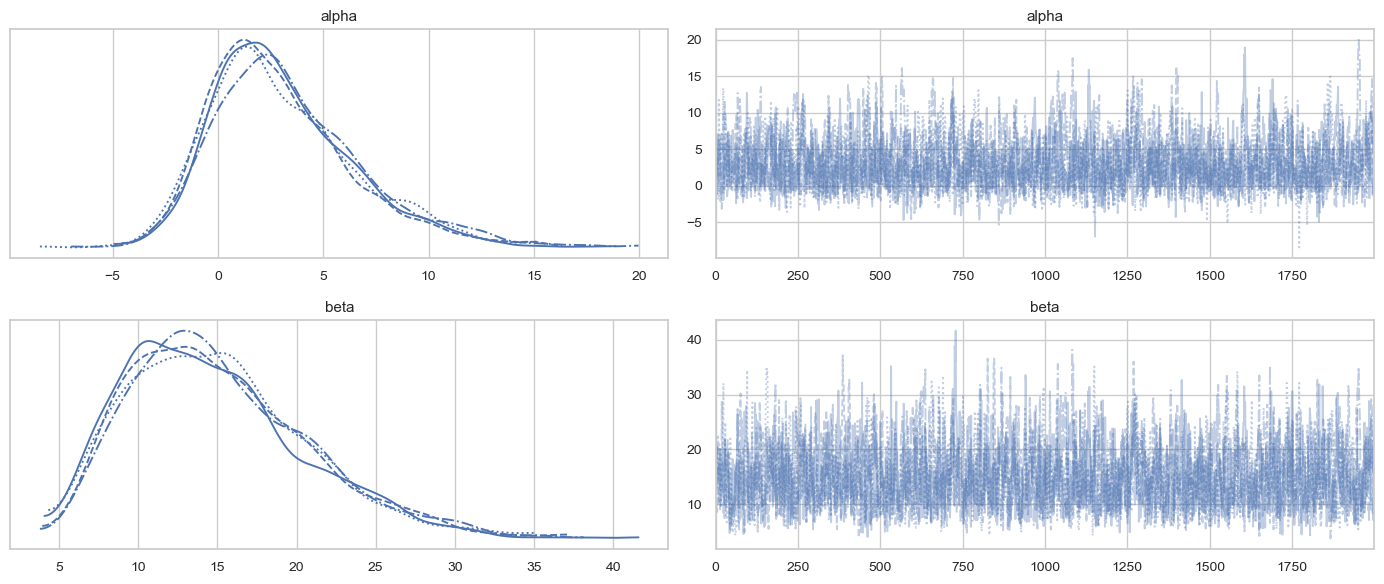

In [11]:
az.plot_trace(
    trace_logistic,
    var_names=["alpha", "beta"],
    figsize=(14, 6)
)

plt.tight_layout();

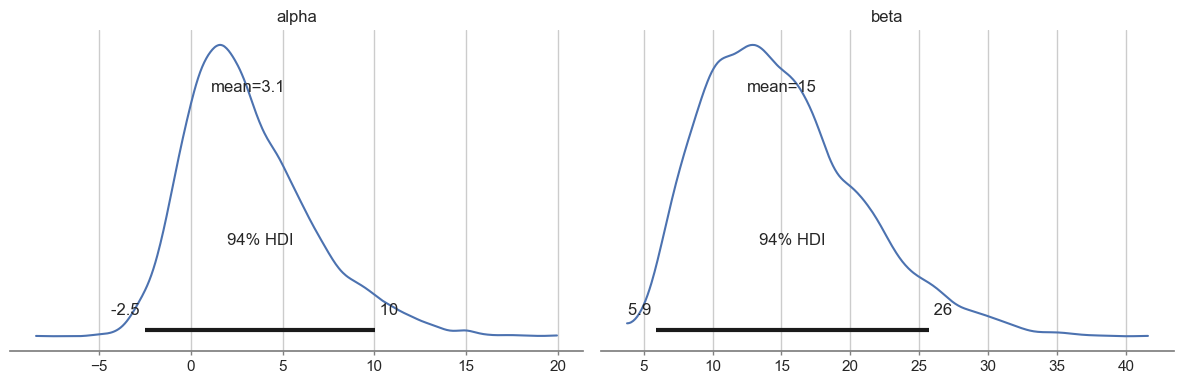

In [12]:
az.plot_posterior(
    trace_logistic,
    var_names=["alpha", "beta"],
    figsize=(12, 4)
)

plt.tight_layout();

In [13]:
posterior = trace_logistic.posterior

alpha_mean = posterior["alpha"].mean().item()
beta_mean = posterior["beta"].mean().item()

x_grid = np.linspace(
    x_scaled.min(),
    x_scaled.max(),
    200
)

p_pred = 1 / (1 + np.exp(-(alpha_mean + beta_mean * x_grid)))

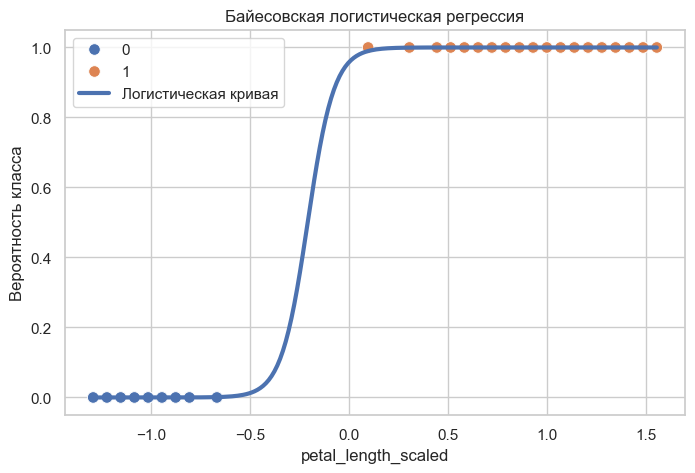

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=x_scaled,
    y=y,
    hue=y,
    palette="deep",
    s=70
)

plt.plot(
    x_grid,
    p_pred,
    linewidth=3,
    label="Логистическая кривая"
)

plt.xlabel("petal_length_scaled")
plt.ylabel("Вероятность класса")

plt.title("Байесовская логистическая регрессия")

plt.legend()

plt.show()